# Unassigned cells: curvature, neighborhoods and the ablation reference state

**An all-zero fate vector is an observed input state, not the absence of a cell.** This notebook studies what that state represents in the dataset and in the trained exclusive-marker FiLM model.

“Unassigned” means negative for all seven measured binary markers. It does not identify a single biological lineage, a dead cell, or a missing segmentation. Cached tables use the label `Unmarked`; figures use **Unassigned**. The encoding-transition audit distinguishes naturally zero vectors from any vectors made zero by exclusivity.

We analyze all 1,100 organoids retained in the existing experiment, 477,789 cells, five folds and three trained seeds. All inference is held out by organoid, at its **observed N**. There is no retraining or counterfactual size sweep in this notebook. It covers (1) the unassigned population, (2) its context and measured curvature, (3) associations with other cell types, (4) held-out model behavior, and (5) what marker-to-zero ablations actually compare.

N bins and collection labels follow the preceding observed-neighborhood study. Size is not interchangeable with collection time. Means give organoids equal weight after averaging cells; bands are 95% organoid bootstrap intervals, conditional on these datasets and fitted models. Fewer than ten contributing organoids gives a blank in the figures.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.analysis.unassigned_cells import UnassignedConfig, run
from src.plotting import unassigned_cells as plots
CONFIG = UnassignedConfig(minimum_cells_per_group=3, minimum_organoids=10,
                          bootstrap_draws=1000, graph_batch_size=8)
OUTPUT = ROOT / 'results_experiments/unassigned_cells/exclusive_v1'
RUN_ANALYSIS = False  # Completed tables/inference are reused. True resumes missing work; never trains.
if RUN_ANALYSIS:
    import torch
    from threadpoolctl import threadpool_limits
    torch.set_num_threads(4)
    with threadpool_limits(limits=4):
        OUTPUT = run(ROOT, CONFIG, device='cuda' if torch.cuda.is_available() else 'cpu')
assert (OUTPUT / 'complete.json').exists()
assert (OUTPUT / 'curvature_qc_complete.json').exists()
from dataclasses import asdict
assert json.loads((OUTPUT / 'settings.json').read_text())['config'] == json.loads(json.dumps(asdict(CONFIG)))
FIGURES = OUTPUT / 'figures'; FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'font.size':9, 'axes.titlesize':10, 'figure.dpi':120})
def show(fig, name):
    fig.savefig(FIGURES / f'{name}.png', dpi=170, bbox_inches='tight')
    fig.savefig(FIGURES / f'{name}.pdf', bbox_inches='tight')
    plt.show(); plt.close(fig)
print(json.dumps(json.loads((OUTPUT / 'complete.json').read_text()), indent=2))
display(pd.read_csv(OUTPUT / 'unassigned_provenance.csv'))


{
  "cells": 477789,
  "unassigned_cells": 125148,
  "organoids": 1100,
  "unassigned_organoids": 1063,
  "checkpoints": 15,
  "maximum_saved_baseline_error": 9.5367431640625e-07
}


,original_markers,n_cells
0,unmarked,125148


## Figure 1 — How common are unassigned cells, and what curvature do they have?

The audit finds **125,148 unassigned cells**, all already negative for the marker panel before exclusivity. None was newly made unassigned by the exclusivity rules. They account for 26.2% of all cells and occur in 1,063 organoids. This pooled cell fraction differs from the equally weighted organoid fractions plotted in A.

B ranks each cell's measured Gaussian curvature among all cells in the same organoid. C shows the fraction with negative measured curvature. These figures characterize the entire unassigned population, not only unassigned cells neighboring LGR5.

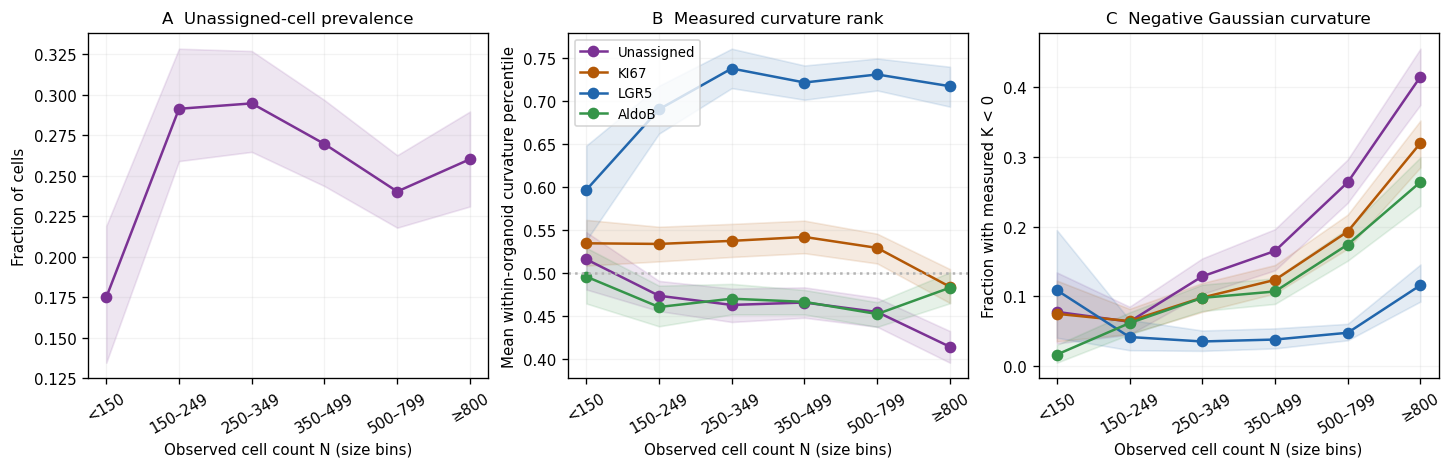

In [2]:
show(plots.population(OUTPUT), 'figure_1_unassigned_population')

## Figure 2 — Heterogeneity, outliers and anatomical context

A checks sensitivity of unassigned mean curvature to the **same configured outlier-interpolation routine used in the training pipeline** (global 0.5th/99.5th-percentile thresholds, neighbor interpolation). Raw measurements are retained and displayed separately. Reapplying this routine is a processing sensitivity check, not proof that every changed value is erroneous. Both curves use K×A/(4π), with measured organoid area. The isolated depression of the raw mean in N=150–249 is particularly sensitive to extreme values; do not interpret it as a biological minimum without checking the rank-based results.

B groups unassigned centers by the strict majority (>50%) of their immediate neighbors. If no fate has a majority, the context is Mixed; an unassigned-majority neighborhood is its own context. **Every center in this panel remains unassigned.** Groups can differ in spatial position and other features, so this is not an effect estimate of the neighboring fate. Rare contexts have insufficient support and remain in the exported tables rather than being forced into a figure.

C uses only the circumference-qualified crypt territories established in the preceding notebook: a supported minimum or flat section near s=1 and at least ten cells assigned inside s≤1. Original nearest-crypt assignments are preserved. Nonqualifying and undetected crypts are excluded from position estimates. The neck band is 0.8–1.2; low-N support is insufficient. These anatomical estimates are conditional on detectable, qualified crypts.

Outlier-processing audit: {'targets_changed': 4778, 'thresholds': {'0': [-0.2019859567284584, 0.23654115587472915]}, 'quantiles': [0.005, 0.995]}


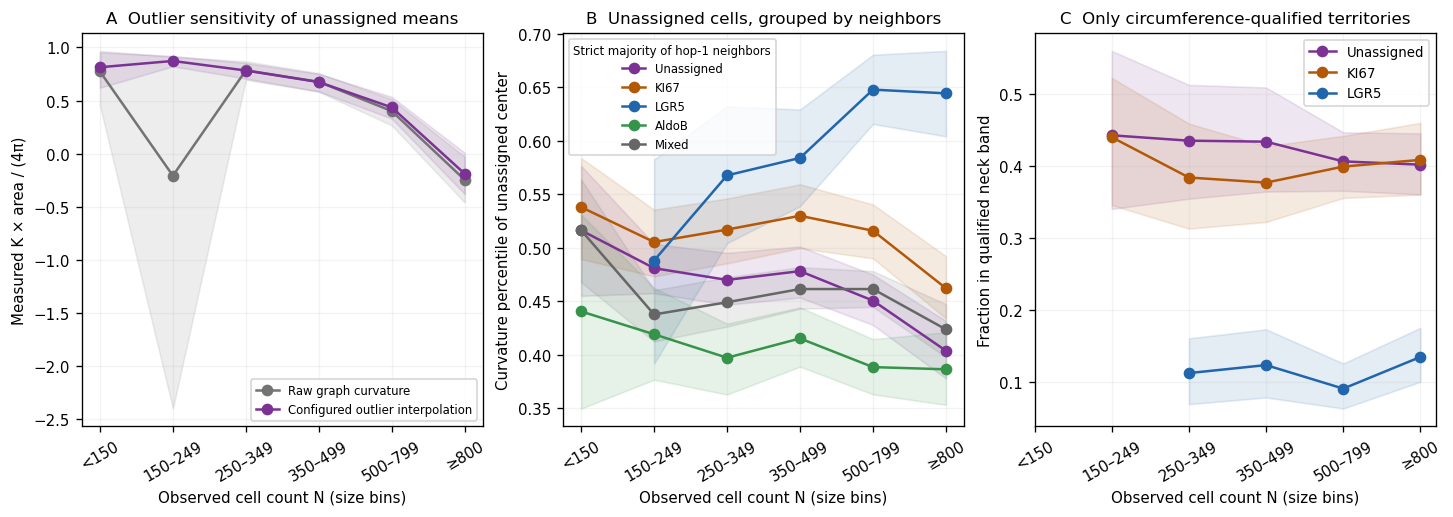

,majority_neighbor_context,cells,organoids
0,Agr2,296,120
1,AldoB,7201,773
2,Chroma,3,3
3,KI67,9223,935
4,LGR5,1795,473
5,Lysozyme,6,6
6,Mixed,20300,1022
7,Unmarked,86324,937


In [3]:
show(plots.context(OUTPUT), 'figure_2_context_and_quality')
display(pd.read_csv(OUTPUT / 'context_support.csv').rename(columns={'context':'majority_neighbor_context'}))
print('Outlier-processing audit:', json.loads((OUTPUT / 'curvature_qc_complete.json').read_text()))

## Figure 3 — What surrounds an unassigned cell?

Exact hop-1 and hop-2 rings exclude the center; hop 2 also excludes hop 1. Left panels show neighbor marker fractions. Right panels subtract the expected composition of other cells in the same organoid, excluding the center, in percentage points. This controls descriptively for marker abundance; it is not a fitted spatial null model or a test of cell–cell attraction.

Concentration of unassigned cells next to one another matters for interpreting ablations: naturally unassigned cells need not occupy the same contexts as the marker-positive cells we convert to zero.

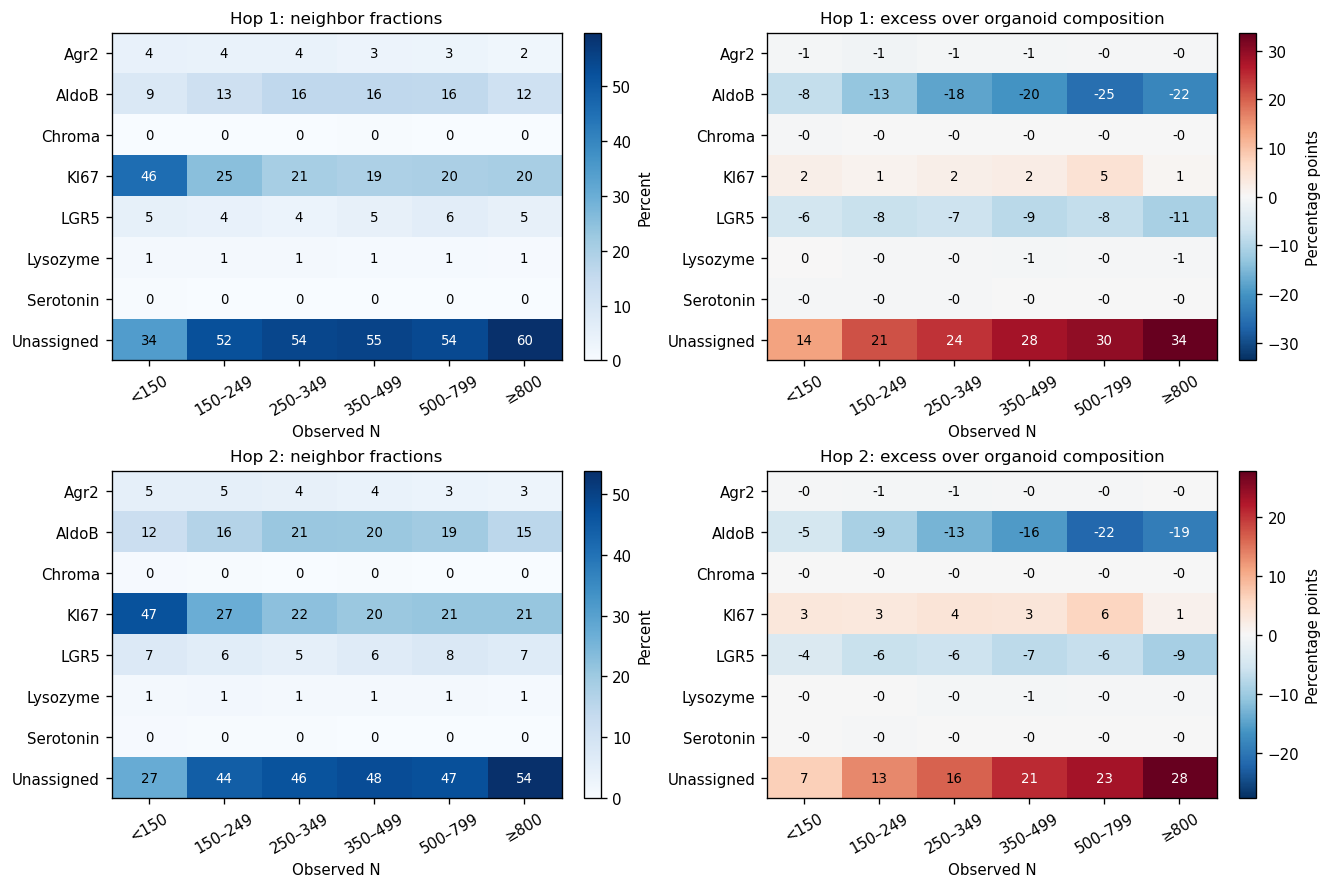

In [4]:
show(plots.neighborhoods(OUTPUT), 'figure_3_unassigned_neighborhoods')

## Figure 4 — How does nearby unassigned tissue correlate with other cell types?

For each center fate, compare cells with at least one unassigned cell in the selected ring against cells without one, **within the same organoid and center fate**. Both groups must contain at least three cells. The heatmaps show the mean difference in measured curvature percentile; negative means the centers near unassigned cells have lower curvature. Centers are counted once per comparison, not once for every incident edge.

C additionally compares only cells of the same exact hop-1 degree. Within each organoid, eligible degree-stratum contrasts are weighted by the smaller of the two group counts, then organoids are weighted equally. This checks whether simple degree differences explain the association. It does not match every aspect of neighborhood composition or position. At hop 2, few cells lack an unassigned neighbor, so blank cells can reflect lack of a comparison group rather than absence of an association.

Pointwise intervals and support counts are in `neighbor_summary_unmatched.csv` and `neighbor_summary_degree_matched.csv`. These are exploratory associations, not causal effects. Replacing a neighbor's fate necessarily changes composition; an “unassigned effect” cannot be isolated while holding every other fate count and degree fixed.

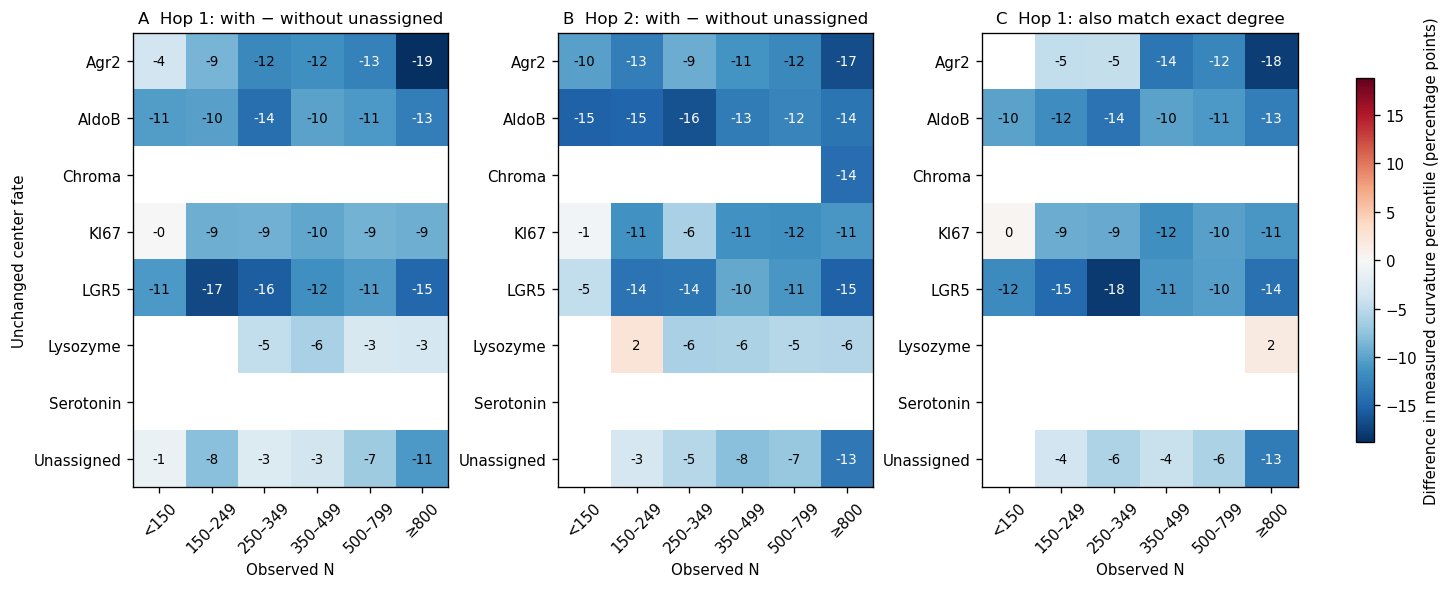

In [5]:
show(plots.neighbor_associations(OUTPUT), 'figure_4_other_cell_types')

## Figure 5 — Does the trained model reproduce these patterns?

Each cell is predicted by the three checkpoints whose training fold excludes its organoid. Seeds are averaged per cell before summarizing organoids. The GNN input remains the exclusive fate panel and log N, with no geometry passed to its head.

A compares measured and predicted curvature **relative to each organoid's own mean**, normalized by measured area. Solid lines use the interpolated targets; dashed lines use held-out predictions. Centering removes the constant baseline, allowing comparison without attributing the global baseline to the GNN. B shows unassigned-cell RMSE for this centered prediction, separately against raw and interpolated targets. It is not total-curvature validation MSE, and the interpolation thresholds reproduce the original cohort-wide preprocessing convention rather than introducing a new train-only evaluation protocol.

C compares the measured and predicted within-organoid differences between marker-positive cells with and without unassigned hop-1 neighbors. The measured curve uses interpolated targets here; raw and rank-based comparisons remain available. Similar mean predictions do not establish accurate cell-level predictions or validate an ablation as a biological intervention.

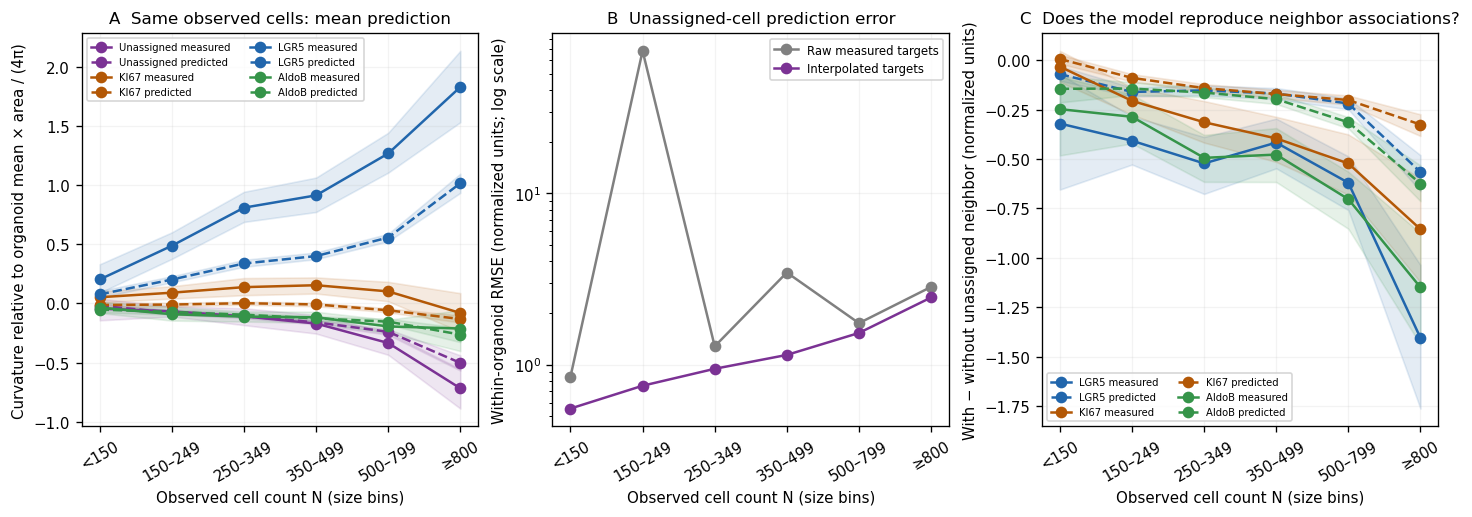

In [6]:
show(plots.prediction_checks(OUTPUT), 'figure_5_heldout_model')

## Figure 6 — Every exclusive single-marker removal is a marker-to-unassigned edit

These are the **existing saved ablation results**, evaluated at observed N, not new deletions or fate assignments. The source's sole positive feature is set to zero while its node, edges, neighbors, N and recipient identity stay unchanged. Each source was verified to have the indicated exclusive fate. The y-axis identifies the recipient whose curvature prediction is read out; recipients can themselves be unassigned.

Colors show predicted K(after)−K(before), normalized by the actual organoid area. We average cases and seeds within organoids before weighting organoids equally. Pair eligibility and sample support differ, so the matrix is not a matched marker-importance ranking. It pools observed sizes; `ablation_by_size.csv` retains the size dependence. In particular, this pooled observed-size KI67 value must not be substituted for the earlier fixed-neighborhood size sweep.

A positive value says **replacing this marker vector by zero in these contexts raises the prediction**. It does not measure an intrinsic curvature contribution of that marker, an effect of removing a cell, or a general property of all naturally unassigned cells.

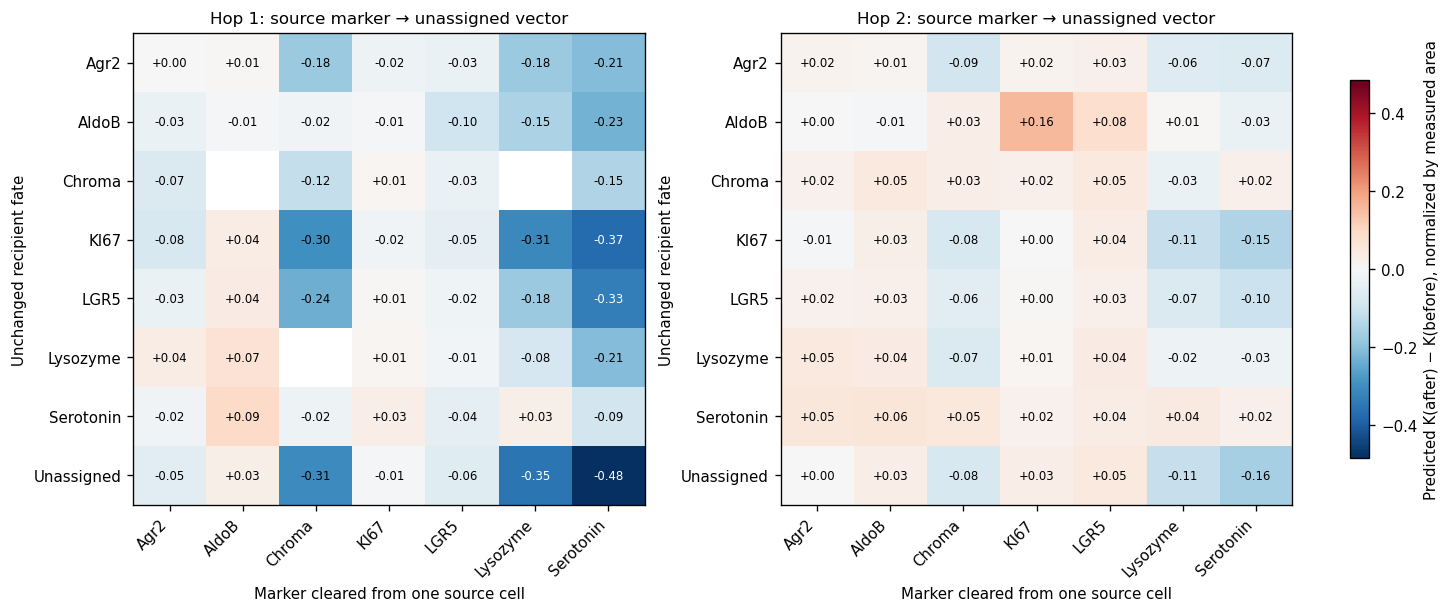

In [7]:
show(plots.ablation_reference(OUTPUT), 'figure_6_marker_to_unassigned')

## Is the replacement state encountered in the same contexts?

The following table compares the fraction of unassigned hop-1 neighbors around ablated source cells with that around naturally unassigned cells **in the same organoid**. Ablated source cells are deduplicated across recipients, hops and seeds before comparison. Only organoids containing both groups contribute. Positive/negative differences indicate different neighborhood composition; this is a limited context check, not a formal out-of-distribution test.

The source sample comes from the existing ablation experiment, so it is not a census of all marker-positive cells. A zero vector can be common in the training data while a particular zero-vector neighborhood remains unusual.

In [8]:
support = pd.read_csv(OUTPUT / 'ablation_source_context.csv')
display(support[support.metric == 'difference'][['source_marker_name','mean','low','high','n_organoids']].rename(
    columns={'mean':'source_minus_natural_unassigned_neighbor_fraction'}))


,source_marker_name,source_minus_natural_unassigned_neighbor_fraction,low,high,n_organoids
2,Agr2,-0.307001,-0.320442,-0.294947,1019
5,AldoB,-0.328558,-0.340512,-0.316858,883
8,Chroma,-0.402066,-0.429192,-0.377535,415
11,KI67,-0.215233,-0.225088,-0.206248,1048
14,LGR5,-0.408149,-0.422947,-0.393472,900
17,Lysozyme,-0.374042,-0.390867,-0.358193,855
20,Serotonin,-0.433579,-0.457558,-0.411738,567


## Why an all-zero input node is not computationally silent

A naturally unassigned node and a marker-ablated node have identical **initial** feature vectors. Their final embeddings need not match because their neighbors, edges and organoid size differ.

In this two-layer GIN, an unassigned node's first update aggregates marker signals from its neighbors and passes through learned linear maps, normalization, FiLM and nonlinearities. Its hidden state can therefore be nonzero even though its own input is zero. In the second layer, that state is passed to neighboring cells. The node also remains part of graph connectivity and the supplied organoid count. Setting an already-unassigned input to zero is a no-op; deleting the node or blocking its messages would be a different intervention.

The saved `prediction_curves.csv` includes the mean final local-embedding norm for unassigned cells as a numerical check. A nonzero norm establishes that zero input is not zero hidden state; it is not itself a measure of biological or predictive importance.

The present study therefore describes **associations around naturally unassigned cells and model responses to marker-to-zero edits**. It cannot establish which unmeasured lineages or marker-detection failures produced the unassigned population, nor whether those cells mechanically cause neighboring curvature.

In [9]:
report = OUTPUT / 'REPORT.md'
if report.exists(): display(Markdown(report.read_text()))

# Unassigned cells and the meaning of marker ablations

**The zero fate vector is a common, spatially structured and heterogeneous reference state. It should not be interpreted as a neutral cell or as removing a cell.** The observational and model results below explain why this matters for every exclusive-marker ablation.

We analyzed 477,789 cells from the original 1,100 filtered organoids and evaluated all 15 trained FiLM checkpoints at observed N, with each organoid held out from its predicting fold. No training was repeated. Six figures, the processing audit and the context-comparison table are displayed in `experiments/unassigned_cell_analysis.ipynb`.

## Findings and figures

**1. Unassigned cells are numerous and were not created by exclusivity — Figure 1.** There are 125,148 unassigned cells (26.2% of all cells) in 1,063 organoids. Every one was already negative for the seven-marker panel before exclusivity. Unassigned is therefore an observed measurement category, but does not identify a unique biological cell type. The organoid-weighted prevalence ranges from 17.5% in N<150 to approximately 24–29% in the other size bins.

**2. Their curvature depends strongly on context — Figure 2B.** At N=500–799, unassigned centers in LGR5-majority neighborhoods average the 65th within-organoid curvature percentile; those in AldoB-majority neighborhoods average the 39th, and those in KI67-majority neighborhoods the 52nd. All centers in this comparison have the same zero vector. Context groups are descriptive and differ in position and other features, so these differences are not effects of adding a particular neighboring fate. Around 69% of unassigned cells have a strict majority of unassigned hop-1 neighbors.

**3. Unassigned cells occupy domains rather than being randomly dispersed — Figure 3.** Their mean unassigned-neighbor fraction is approximately 34% at N<150 and 52–60% in the other bins. This exceeds the corresponding same-organoid availability by approximately 14–34 percentage points. Similar, weaker structure extends to hop 2. Qualified-neck estimates in Figure 2C retain the preceding circumference-based restriction; missing small crypts are not treated as anatomically unassigned tissue.

**4. Nearby unassigned cells correlate with lower curvature in several marked populations — Figure 4.** Within the same organoid and recipient fate, the N=250–349 hop-1 with-versus-without-unassigned-neighbor difference is −15.5 curvature-percentile points for LGR5, −14.1 for AldoB, −12.1 for Agr2 and −9.1 for KI67. Pointwise organoid-bootstrap intervals exclude zero for these examples. The broad pattern persists when comparisons are restricted to the same exact degree. Rare fates and hop-2 comparisons often lack sufficient support. These associations do not establish that unassigned cells cause curvature changes: other composition and fine spatial context remain unmatched.

**5. The model captures part of this structure, with attenuated neighbor contrasts — Figure 5.** After reproducing the configured target-outlier interpolation, the mean predicted centered curvature of unassigned cells follows the measured mean reasonably closely at intermediate sizes. It is less negative than the measured mean at the largest sizes. For LGR5, KI67 and AldoB recipients, predicted with-versus-without-unassigned contrasts are generally smaller than the measured contrasts. For example, at N=250–349 the LGR5 measured normalized contrast is −0.523 versus a predicted −0.153. Agreement of population means does not imply accurate individual predictions or validate a counterfactual edit.

**6. Naturally unassigned and newly zeroed cells occupy different contexts — table after Figure 6.** Comparing within the same organoids, ablated KI67 sources have 21.5 percentage points fewer unassigned hop-1 neighbors than naturally unassigned cells. The difference is 40.8 points for ablated LGR5 sources; all seven source-marker comparisons are negative, ranging from 21 to 43 points. Sources are deduplicated across recipients, hops and seeds, but are still the sampled ablation sources rather than a census of all marker-positive cells. This establishes a contextual distribution difference, not a formal out-of-distribution diagnosis for each edit.

## Consequences for interpreting ablations

Figure 6 expresses the existing observed-size ablations explicitly as **source marker → unassigned vector**, with recipient identity preserved. It also includes unassigned recipients, which show substantial predicted responses to changes in their neighbors. Pair cohorts differ, so matrix values are not a matched ranking of marker importance. Pooled observed-size effects are not the fixed-graph size sweeps from the earlier notebook.

The input representation of a naturally unassigned and an ablated cell is identical, but its surrounding graph is not necessarily typical of naturally unassigned tissue. In this two-layer GIN, an all-zero node receives neighbors' marker signals and undergoes learned transformations, normalization and FiLM. Its resulting hidden representation can be nonzero and can enter the next layer's aggregation at neighboring cells. Mean final embedding norms for unassigned cells are approximately 14–18 across size bins; the norm is a computation check, not an importance score. Deleting a node or suppressing its messages would be a different intervention from setting its fate vector to zero.

Consequently, ablations measure a conditional change relative to a learned zero-vector state. They do not isolate an intrinsic contribution of the removed marker. The observed structure of unassigned cells makes this reference-state issue material, while the present analysis does not establish that it explains the earlier KI67 U-shaped sweep. That specific question requires comparing matched contexts and alternative feature edits on fixed neighborhoods.

## Curvature quality and validation

Raw curvature extremes severely distort the N=150–249 unassigned mean: dimensionless mean curvature is −0.209 before the configured interpolation and +0.873 afterwards. Raw within-organoid curvature ranks are much more stable. Reapplying the existing global 0.5th/99.5th-percentile target-outlier routine changes 4,778 cells across all fates. Raw measurements remain available. Interpolated targets are a processing sensitivity check, not a claim that every changed measurement was invalid. Prediction RMSE in Figure 5 is for curvature centered within each organoid, with area normalization, not the original total-curvature validation metric.

All statistics average cells and, for model summaries, seeds before weighting organoids equally. Intervals condition on the fitted models and these datasets; they do not quantify independent experimental-batch uncertainty. Collection-specific summaries and degree-matched contrasts are exported separately. Full-graph intact predictions reproduce the saved ablation baselines with maximum absolute transformed-curvature discrepancy 9.54×10⁻⁷. Tests verify context assignment and the eligibility, sign and weighting of within-organoid degree-matched contrasts. The exclusive data, previous notebooks and checkpoints were retained.
